### Data Cleaning and Preprocessing 
### Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [3]:
# --- 1. Load Data and Initial Cleaning ---
df = pd.read_csv("cardio_train.csv", sep=';')

# Drop 'id' column
df = df.drop('id', axis=1)
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
# Convert 'age' from days to years
df['age'] = (df['age'] / 365).astype(int)

In [5]:
# --- 2. Handle Missing Values ---
# Check for missing values (Output confirms no missing values)
print("--- Missing Value Check ---")
print(df.isnull().sum())

--- Missing Value Check ---
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [6]:
# Outlier Detection & Removal (BP, Height, Weight) - DO THIS FIRST
df = df[(df['ap_hi'] <= 250) & (df['ap_hi'] >= 70)]
df = df[(df['ap_lo'] <= 200) & (df['ap_lo'] >= 40)]
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

In [7]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_columns = ['height','weight','ap_hi','ap_lo']
df[scaled_columns] = scaler.fit_transform(df[scaled_columns])


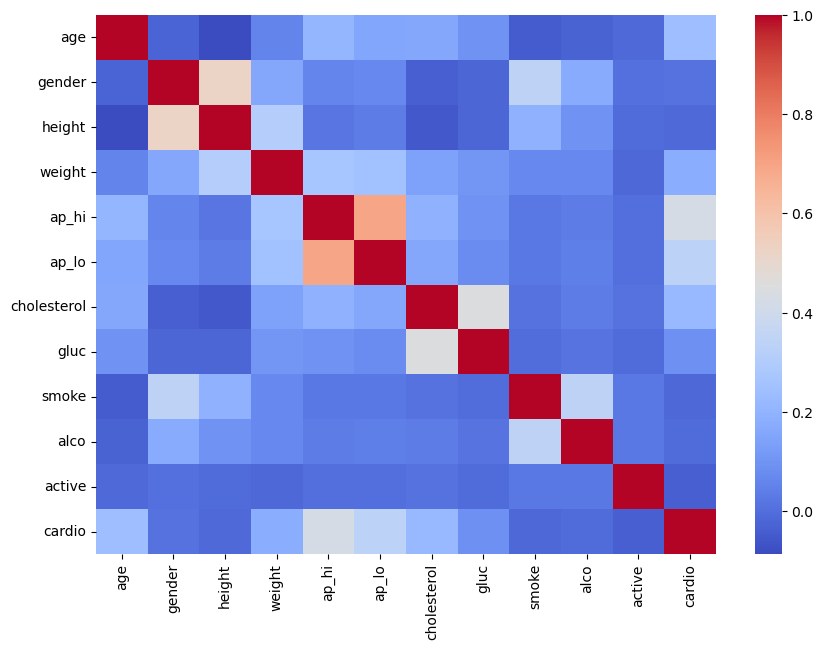

In [8]:
#EDA Visualizations
#1.Correlation Heatmap
%matplotlib inline
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

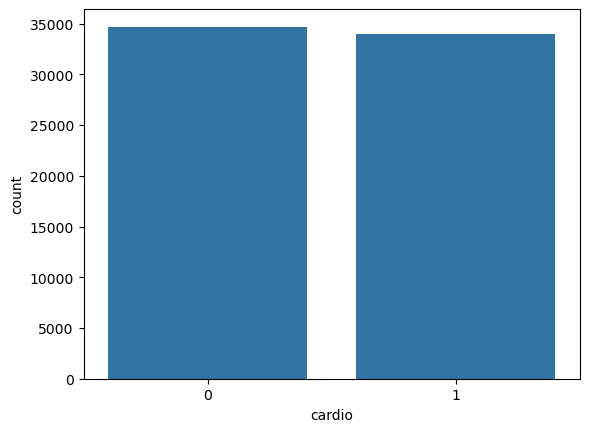

In [9]:
#2.Target Distribution
%matplotlib inline
sns.countplot(x='cardio', data=df)
plt.show()

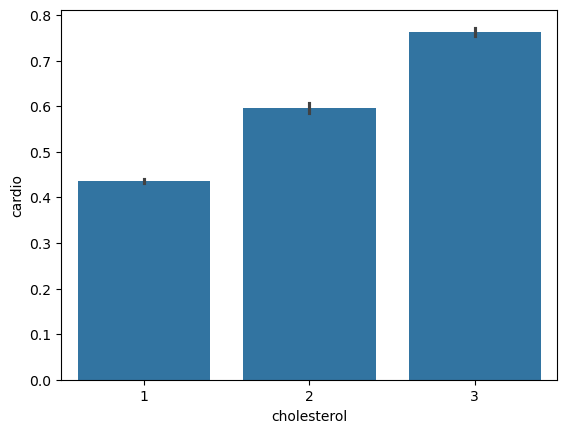

In [10]:
#3.Cholesterol vs Disease
%matplotlib inline
sns.barplot(x='cholesterol', y='cardio', data=df)
plt.show()

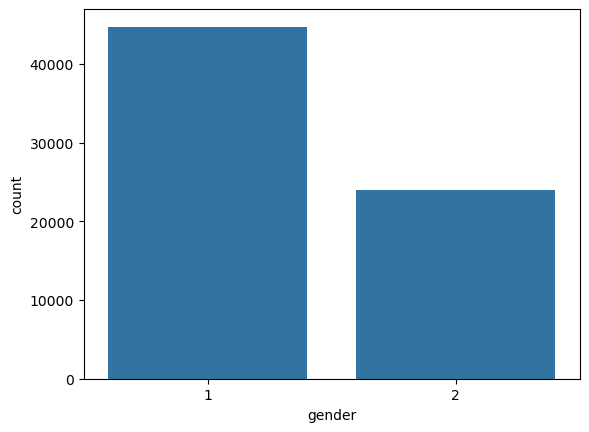

In [11]:
#Gender Count
sns.countplot(x='gender', data=df)
plt.show()


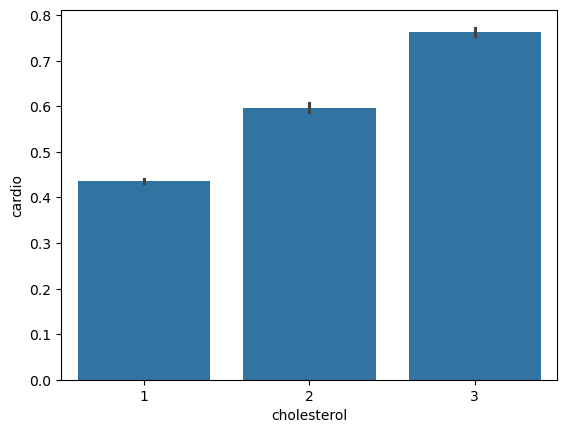

In [12]:
#Cholesterol vs Disease
sns.barplot(x='cholesterol', y='cardio', data=df)
plt.show()


In [13]:
#Show the last 5 rows of the dataframe.
df.tail(5)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,52,2,0.453804,0.131889,-0.394914,-0.143089,1,1,1,0,1,0
69996,61,1,-0.820211,3.631079,0.798313,0.890465,2,2,0,0,1,1
69997,52,2,2.364826,2.161419,3.184766,0.890465,3,1,0,1,0,1
69998,61,1,-0.183204,-0.148046,0.500006,-0.143089,1,2,0,0,0,1
69999,56,1,0.708607,-0.148046,-0.394914,-0.143089,2,1,0,0,1,0


In [14]:
#Print the number of rows and columns in the dataframe.
df.shape


(68680, 12)

In [15]:
#Find the average age of all people.
df['age'].mean()

52.82986313337216

In [16]:
#Count how many people have heart disease.
df['cardio'].value_counts()

cardio
0    34688
1    33992
Name: count, dtype: int64

In [17]:
#Show the unique cholesterol levels.
df['cholesterol'].unique()


array([1, 3, 2], dtype=int64)

In [18]:
#Show the unique cholesterol levels.
df['height'].unique()


array([ 0.45380384, -1.07501415,  0.07159935,  0.58120534, -1.71202164,
       -0.94761265,  1.72781884, -0.82021115, -0.05580215,  1.09081134,
        2.11002333,  0.96340984,  0.70860684, -1.32981715, -0.31060515,
       -0.18320365, -1.45721864, -0.69280965,  0.19900084, -1.20241565,
       -0.56540815,  1.34561434,  0.83600834, -1.58462014,  2.87443233,
       -2.09422614,  1.85522033,  1.98262183,  3.00183383,  2.61962933,
        0.32640234,  2.36482633,  1.21821284,  1.47301584, -0.43800665,
        2.49222783,  1.60041734,  2.23742483, -1.96682464, -2.85863514,
       -1.83942314, -2.60383214, -2.22162764,  2.74703083, -2.34902914,
       -2.98603663,  3.89364432, -3.11343813,  4.27584882, -2.47643064,
       -2.73123364,  4.02104582, -3.36824113,  3.76624282,  3.25663683,
       -3.87784713, -3.62304413,  3.12923533, -3.49564263,  3.51143982,
        3.38403832, -4.38745313,  3.63884132, -4.13265013, -3.75044563,
       -3.24083963, -4.00524863,  5.42246231,  4.14844732, -4.26

In [19]:
#Calculate the average weight grouped by gender.
df.groupby('gender')['weight'].mean()

gender
1   -0.114950
2    0.214712
Name: weight, dtype: float64

In [20]:
#Find how many people are physically active.
df['active'].value_counts()

active
1    55181
0    13499
Name: count, dtype: int64

In [21]:
#Find how many people are physically active.
df['height'].value_counts()

height
 0.071599    5759
-0.565408    4942
 0.708607    4606
 0.453804    4327
-0.055802    3345
             ... 
-4.132650       3
-3.877847       2
 3.766243       2
 5.422462       1
-4.260052       1
Name: count, Length: 70, dtype: int64

In [22]:
#Convert height from days to years and print first 5.
(df['age'] / 365).head(5)


0    0.136986
1    0.150685
2    0.139726
3    0.131507
4    0.128767
Name: age, dtype: float64

In [23]:
#Find the row with highest cholesterol.
df[df['cholesterol'] == df['cholesterol'].max()]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1,55,1,-1.075014,0.761743,0.798313,0.890465,3,1,0,0,1,1
2,51,1,0.071599,-0.707916,0.201699,-1.176643,3,1,0,0,0,1
6,60,1,-0.947613,1.321614,0.201699,-0.143089,3,1,0,0,1,0
7,61,2,1.727819,1.461581,0.201699,0.890465,3,3,0,0,1,1
24,45,1,0.708607,-0.427981,1.394926,0.890465,3,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
69940,58,1,0.453804,0.271857,0.798313,-0.143089,3,1,0,0,1,1
69949,60,1,0.326402,-0.427981,2.409169,0.373688,3,1,0,0,1,1
69956,58,1,-0.820211,0.061905,-0.394914,-0.143089,3,3,0,0,1,0
69970,61,2,1.090811,2.021452,0.798313,-0.143089,3,1,1,1,0,1


In [24]:
#Create a new column BMI = weight / (height/100)^2.
df['BMI'] = df['weight'] / ( (df['height']/100) ** 2 )
df['BMI']

0       -4.117182e+04
1        6.591440e+03
2       -1.380905e+06
3        1.633489e+04
4       -1.097028e+04
             ...     
69995    6.404318e+03
69996    5.397397e+04
69997    3.864920e+03
69998   -4.410912e+04
69999   -2.948397e+03
Name: BMI, Length: 68680, dtype: float64

In [25]:
#Filter rows where age > 50 years.
df[df['age'] > 50*365]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI


In [26]:
#Sort the dataframe by age in descending order.
df.sort_values(by='age', ascending=False)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
51233,64,1,-0.947613,0.201873,-0.394914,-0.143089,2,2,0,0,1,1,2248.104677
7064,64,2,0.071599,-0.078062,0.798313,0.890465,1,1,0,0,1,1,-152272.919535
7102,64,1,-2.221628,-0.917868,-0.991527,-1.176643,1,1,0,0,1,0,-1859.677284
7100,64,1,-0.947613,0.411824,1.394926,1.924019,3,3,0,0,1,0,4586.172304
42042,64,2,-0.310605,-0.917868,0.201699,-0.143089,1,1,0,0,1,0,-95139.927529
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26286,39,1,-0.565408,-1.197803,-1.588141,0.890465,1,1,0,0,1,0,-37468.064481
55905,30,1,-0.565408,-1.057835,-0.991527,-1.176643,1,1,0,0,1,0,-33089.786034
6219,29,1,1.345614,-1.057835,-0.394914,-0.143089,1,1,0,0,1,0,-5842.206128
30666,29,1,-0.692810,-1.057835,-0.394914,-0.143089,1,1,0,0,1,0,-22038.916124


In [27]:
#Find correlation between height and weight (numeric output only).
df['height'].corr(df['weight'])

0.31114063342371495

### Model Creation 

In [29]:
# Implement selected Algorithm without use of Library.  
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            dw = np.dot(X.T, (y_pred - y)) / len(y)
            db = np.sum(y_pred - y) / len(y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return [1 if i > 0.5 else 0 for i in y_pred]


In [30]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return (y_pred >= 0.5).astype(int)


In [31]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X = np.array([[1,2],[2,3],[3,4],[4,5]])
y = np.array([0,0,1,1])

model = LogisticRegression()
model.fit(X, y)

predictions = model.predict(X)
print(predictions)


[0 0 1 1]


In [32]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

In [33]:
y_pred = model.predict(X_test)
print("Predicted:", y_pred)
print("Actual:", y_test)


Predicted: [0 1]
Actual: [0 1]


In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


### Model Evaluation 

In [36]:
def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)


In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('cardio_train.csv', sep=';')
df['age'] = (df['age'] / 365.25).astype(int)
df = df[(df['ap_hi'] < 250) & (df['ap_hi'] > 60)]
df = df[(df['ap_lo'] < 200) & (df['ap_lo'] > 40)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# 3. Define Features (X) and Target (y)
X = df.drop(['id', 'cardio'], axis=1).values
y = df['cardio'].values

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the features (This creates X_train_scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled and X_test_scaled are now defined and ready for training.")

X_train_scaled and X_test_scaled are now defined and ready for training.


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the library model
lib_model = LogisticRegression()
lib_model.fit(X_train_scaled, y_train)

# Prediction and Accuracy
lib_pred = lib_model.predict(X_test_scaled)
lib_accuracy = accuracy_score(y_test, lib_pred)
print(f"Library Accuracy: {lib_accuracy:.4f}")

Library Accuracy: 0.7258


In [81]:
#Compute metrics and check for overfitting/underfitting.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def perform_task_4(model, X_train, X_test, y_train, y_test):
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # 1. Compute Metrics
    print("--- MODEL EVALUATION ---")
    print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.4f}")
    #print("\nClassification Report:\n", classification_report(y_test, test_preds))
    print(classification_report(y_test, y_pred))

    
    # 2. Check for Overfitting/Underfitting 
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    
    if train_acc > test_acc + 0.1:
        print("Status: Potential Overfitting detected (High Train Acc, Lower Test Acc).")
    elif train_acc < 0.6:
        print("Status: Potential Underfitting detected (Low Accuracy on both).")
    else:
        print("Status: Model is well-generalized.")

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

In [83]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def perform_task_4(model, X_train, X_test, y_train, y_test):
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    print("\n--- MODEL EVALUATION ---")
    
    # Metrics
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_preds))

    # Overfitting / Underfitting Check
    if train_acc > test_acc + 0.1:
        print("Status: Potential Overfitting detected.")
    elif train_acc < 0.6:
        print("Status: Potential Underfitting detected.")
    else:
        print("Status: Model is well-generalized.")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
